# **Importing**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import time
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# **Loading Data**

In [2]:
df = pd.read_csv("GuestSatisfactionPredictionMilestone2.csv")
df.head()

,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,thumbnail_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,street,neighbourhood,neighbourhood_cleansed,city,state,zipcode,market,smart_location,country_code,country,latitude,longitude,is_location_exact,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,square_feet,nightly_price,price_per_stay,security_deposit,cleaning_fee,guests_included,extra_people,minimum_nights,maximum_nights,number_of_reviews,number_of_stays,first_review,last_review,guest_satisfaction,requires_license,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification
0,21514496,https://www.airbnb.com/rooms/21514496,PRIVATE BEDROOM DOWNTOWN 2 BED/ 2 BATH #5,Beautiful 2 bedroom 2 bathroom furnished apart...,Each apartment is fully furnished and consists...,Beautiful 2 bedroom 2 bathroom furnished apart...,NaN,***Note that the pictures on the website may o...,NaN,NaN,This is a private room listing which means tha...,NaN,NaN,3881880,https://www.airbnb.com/users/show/3881880,Andrey,10/15/2012,"San Diego, California, United States",My name is Andrey and I am the owner of Kamo H...,within a few hours,90%,NaN,f,Pacific Beach,19.0,19.0,t,t,"San Diego, CA, United States",East Village,East Village,San Diego,CA,92101.0,San Diego,"San Diego, CA",US,United States,32.71104,-117.14980,t,Apartment,Private room,1,1.0,1.0,2.0,Real Bed,"{TV,Wifi,""Air conditioning"",Pool,Kitchen,""Free...",NaN,$40.00,$200.00,$0.00,$50.00,1,$0.00,5,1125,1,2,11/17/2017,11/17/2017,Average,f,f,f,strict_14_with_grace_period,f,f
1,990185,https://www.airbnb.com/rooms/990185,4 bed/2 ba Family Retreat in SD,We feel our house is a great place for a famil...,Our house is ideal for large families or group...,We feel our house is a great place for a famil...,Neighborhood Mira Mesa is a culturally diverse...,NaN,NaN,Our guests may use the BBQ grill.,"Although we will be out of town, we will have ...",This is our primary home. Thank you for leavi...,NaN,4888818,https://www.airbnb.com/users/show/4888818,Teresa,1/29/2013,"San Diego, California, United States","We're from San Diego, California. We love to ...",within a few hours,100%,NaN,f,Mira Mesa,1.0,1.0,t,f,"San Diego, CA, United States",Mira Mesa,Mira Mesa,San Diego,CA,92126.0,San Diego,"San Diego, CA",US,United States,32.91785,-117.14942,t,House,Entire home/apt,8,2.0,4.0,5.0,Real Bed,"{TV,""Cable TV"",Wifi,Kitchen,""Free parking on p...",NaN,$151.00,$604.00,$100.00,$100.00,5,$15.00,4,15,13,26,8/2/2013,7/31/2019,High,f,f,f,moderate,f,f
2,19878244,https://www.airbnb.com/rooms/19878244,San Diego Dream Villa,"Zen, Luxury and the Best Location in Americas ...","San Diego Dream Villa, this unique and luxurio...","Zen, Luxury and the Best Location in Americas ...",This amazing house is located within a few min...,Im always available to make your trip experien...,"If you are bringing your car, remember that SD...",A couple of days before your arrival you will ...,Let me know if you need anything :),Always inform owner/manager if you are traveli...,NaN,9832430,https://www.airbnb.com/users/show/9832430,Rick,11/5/2013,"San Diego, California, United States",Hospitality is my passion and making your vaca...,within a few hours,100%,NaN,t,Hillcrest,12.0,12.0,t,f,"San Diego, CA, United States",Hillcrest,Midtown,San Diego,CA,92103.0,San Diego,"San Diego, CA",US,United States,32.74337,-117.16539,t,Apartment,Entire home/apt,3,1.0,1.0,1.0,Real Bed,"{TV,Internet,Wifi,""Air conditioning"",Kitchen,""...",NaN,$119.00,$119.00,$200.00,$90.00,1,$14.00,1,1125,85,170,7/23/2017,7/16/2019,Very High,f,f,f,strict_14_with_grace_period,f,f
3,24561458,https://www.airbnb.com/rooms/24561458,St

# **BASIC CLEAN**

In [3]:
Y = df['guest_satisfaction']
X = df.drop(columns=['guest_satisfaction'])


In [4]:
drop_columns = ['thumbnail_url', 'host_acceptance_rate','square_feet','is_business_travel_ready','requires_license','id','country_code','summary',
                'host_url','listing_url','name','neighbourhood','street','host_has_profile_pic','country','smart_location','market','state','city',
                'bed_type','require_guest_phone_verification','require_guest_profile_picture', 'host_name', 'space','host_total_listings_count',
                'latitude', 'longitude']
X.drop(columns=drop_columns, inplace=True)

In [5]:
X['extra_people'] = X['extra_people'].replace(r'[\$,]', '', regex=True).astype(float)
X['nightly_price'] = X['nightly_price'].replace(r'[\$,]', '', regex=True).astype(float)
X['price_per_stay'] = X['price_per_stay'].replace(r'[\$,]', '', regex=True).astype(float)
X['security_deposit'] = X['security_deposit'].replace(r'[\$,]', '', regex=True).astype(float)
X['cleaning_fee'] = X['cleaning_fee'].replace(r'[\$,]', '', regex=True).astype(float)
X['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
X['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
X['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')

# **PreProcessing**

In [6]:
def parse_amenities(amenities_str):
    amenities_str = amenities_str.strip('{}')
    items = [item.strip().strip('"') for item in amenities_str.split(',')]
    return items

X['amenities_parsed'] = X['amenities'].apply(parse_amenities)

amenity_categories = {
    'Basic Necessities': {'Heating', 'Hot water', 'Smoke detector', 'Carbon monoxide detector'},
    'Comfort/Convenience': {'Air conditioning', 'Kitchen', 'Iron', 'Laptop friendly workspace', 'Essentials', 'Hangers'},
    'Technology': {'TV', 'Wifi'},
    'Safety': {'Smoke detector', 'Carbon monoxide detector', 'Lock on bedroom door'},
    'Recreation': {'Pool', 'Gym', 'Hot tub'},
    'Parking': {'Free parking on premises'},
    'Accessibility': {'Elevator', 'Private entrance'}
}

def categorize_amenities(amenities_list):
    categorized = {category: [] for category in amenity_categories}
    for amenity in amenities_list:
        for category, items in amenity_categories.items():
            if amenity in items:
                categorized[category].append(amenity)
    return categorized

X['amenities_categorized'] = X['amenities_parsed'].apply(categorize_amenities)


def create_binary_features(amenities_list):
    binary_features = {}
    all_amenities = set(amenities_list)
    for category, items in amenity_categories.items():
        for item in items:
            binary_features[f'has_{item.lower().replace(" ", "_")}'] = 1 if item in all_amenities else 0
    return binary_features

binary_features_X = X['amenities_parsed'].apply(create_binary_features).apply(pd.Series)


X = X.join(binary_features_X)

X = X.drop(columns=[col for col in ['amenities', 'amenities_parsed', 'amenities_categorized'] if col in X.columns])

print(X.columns)

Index(['description', 'neighborhood_overview', 'notes', 'transit', 'access',
       'interaction', 'house_rules', 'host_id', 'host_since', 'host_location',
       'host_about', 'host_response_time', 'host_response_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_identity_verified', 'neighbourhood_cleansed', 'zipcode',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'nightly_price', 'price_per_stay',
       'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people',
       'minimum_nights', 'maximum_nights', 'number_of_reviews',
       'number_of_stays', 'first_review', 'last_review', 'instant_bookable',
       'cancellation_policy', 'has_hot_water', 'has_smoke_detector',
       'has_carbon_monoxide_detector', 'has_heating', 'has_essentials',
       'has_kitchen', 'has_laptop_friendly_workspace', 'has_hangers',
       'has_air_conditioning', 'has_iron', 'has_tv', 'has

In [7]:
def get_text_columns(X, sample_ratio=0.3, min_avg_len=5, min_unique=3):
    text_columns = []

    for col in X.columns:
        sample = X[col].dropna().sample(frac=min(sample_ratio, 1.0), random_state=42)

        is_text = sample.apply(lambda x: isinstance(x, str) and not x.isnumeric()).mean() > 0.8
        avg_len = sample.apply(lambda x: len(x) if isinstance(x, str) else 0).mean()
        num_unique = X[col].nunique()

        if is_text and avg_len > min_avg_len and num_unique >= min_unique:
            text_columns.append(col)

    return text_columns


text_columns = get_text_columns(X)
print("Text columns in the DataFrame:", text_columns)

Text columns in the DataFrame: ['description', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'host_location', 'host_about', 'host_response_time', 'host_neighbourhood', 'neighbourhood_cleansed', 'property_type', 'room_type', 'cancellation_policy']


In [8]:
def preprocess_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenize with 'english' language
    tokens = word_tokenize(text, language='english')
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

text_columns.remove('host_response_time')
for col in text_columns:
    X[col] = X[col].apply(preprocess_text)

print(X.columns)

Index(['description', 'neighborhood_overview', 'notes', 'transit', 'access',
       'interaction', 'house_rules', 'host_id', 'host_since', 'host_location',
       'host_about', 'host_response_time', 'host_response_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_identity_verified', 'neighbourhood_cleansed', 'zipcode',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'nightly_price', 'price_per_stay',
       'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people',
       'minimum_nights', 'maximum_nights', 'number_of_reviews',
       'number_of_stays', 'first_review', 'last_review', 'instant_bookable',
       'cancellation_policy', 'has_hot_water', 'has_smoke_detector',
       'has_carbon_monoxide_detector', 'has_heating', 'has_essentials',
       'has_kitchen', 'has_laptop_friendly_workspace', 'has_hangers',
       'has_air_conditioning', 'has_iron', 'has_tv', 'has

# **Train & Test Split**

In [9]:
X_train, X_test, y_train , y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# **VISUALIZATIONS**

In [10]:
def get_numeric_columns(X, sample_ratio=0.3):
    numeric_columns = []

    for col in X.columns:
        sample = X[col].dropna().sample(frac=min(sample_ratio, 1.0), random_state=42)

        is_numeric = sample.apply(lambda x: isinstance(x, (int, float))).mean() > 0.8

        if is_numeric:
            numeric_columns.append(col)

    return numeric_columns
def get_categorical_columns(X_train, sample_ratio=0.3, max_unique=2):
    categorical_columns = []

    for col in X_train.columns:
        sample = X[col].dropna().sample(frac=min(sample_ratio, 1.0), random_state=42)

        if sample.nunique() <= max_unique:
            categorical_columns.append(col)

    return categorical_columns
Numerical_cols = get_numeric_columns(X)
Categorical_cols = get_categorical_columns(X)
print("Numerical columns:", Numerical_cols)
print('///////////////////////////////////////////////////////////////////')
#Categorical_cols = [ 'is_location_exact', 'host_identity_verified','host_is_superhost','host_response_rate','instant_bookable' ]
print("categorical columns:", Categorical_cols)


Numerical columns: ['host_id', 'host_listings_count', 'zipcode', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'nightly_price', 'price_per_stay', 'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'number_of_stays', 'has_hot_water', 'has_smoke_detector', 'has_carbon_monoxide_detector', 'has_heating', 'has_essentials', 'has_kitchen', 'has_laptop_friendly_workspace', 'has_hangers', 'has_air_conditioning', 'has_iron', 'has_tv', 'has_wifi', 'has_lock_on_bedroom_door', 'has_gym', 'has_pool', 'has_hot_tub', 'has_free_parking_on_premises', 'has_elevator', 'has_private_entrance']
///////////////////////////////////////////////////////////////////
categorical columns: ['host_is_superhost', 'host_identity_verified', 'is_location_exact', 'instant_bookable', 'has_hot_water', 'has_smoke_detector', 'has_carbon_monoxide_detector', 'has_heating', 'has_essentials', 'has_kitchen', 'has_laptop_friendly_workspace', 'has_hanger

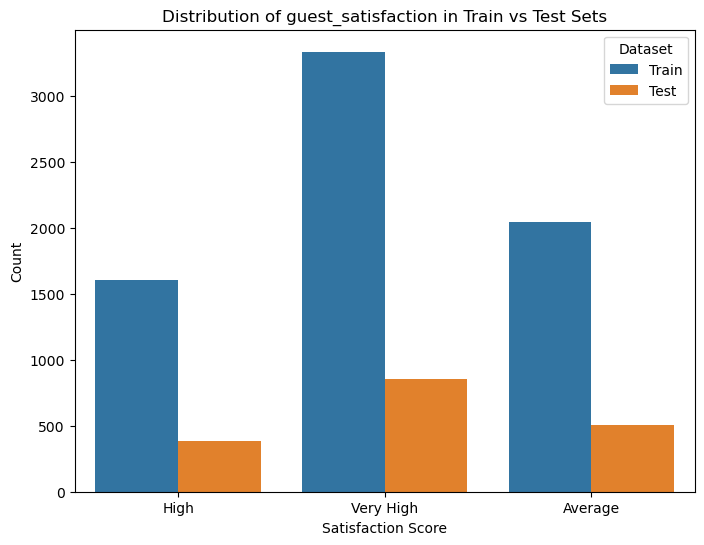

In [11]:
# Combine train and test for comparison
train_data = X_train.copy()
train_data['Set'] = 'Train'
train_data['guest_satisfaction'] = y_train

test_data = X_test.copy()
test_data['Set'] = 'Test'
test_data['guest_satisfaction'] = y_test

combined = pd.concat([train_data, test_data])

plt.figure(figsize=(8,6))
sns.countplot(data=combined, x='guest_satisfaction', hue='Set')
plt.title('Distribution of guest_satisfaction in Train vs Test Sets')
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')
plt.legend(title='Dataset')
plt.show()

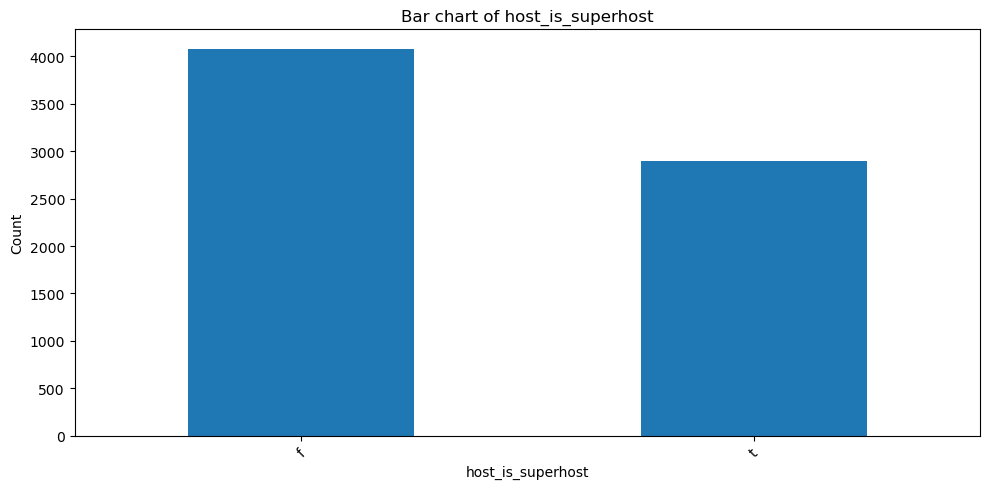

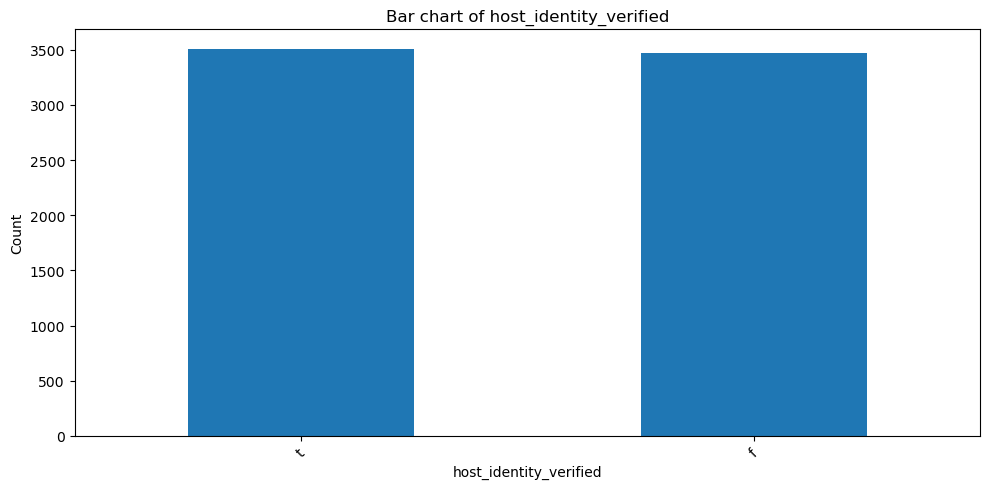

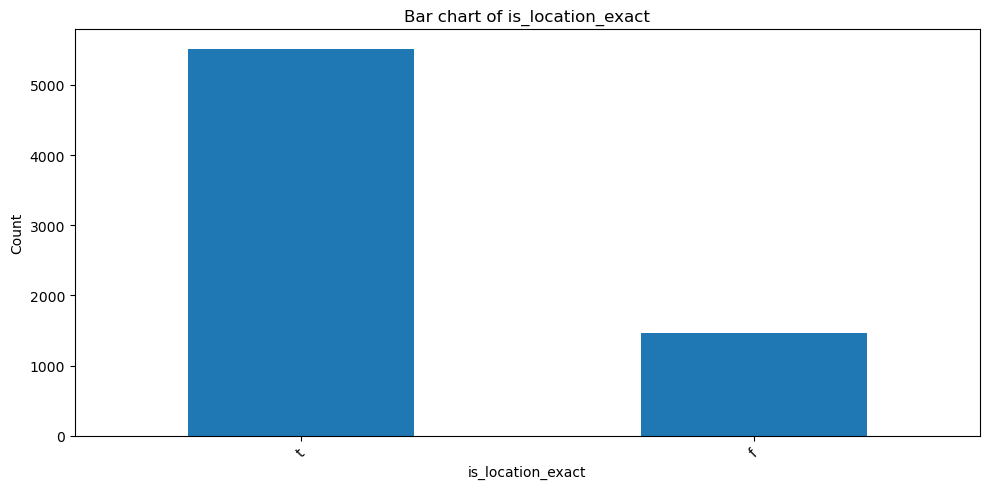

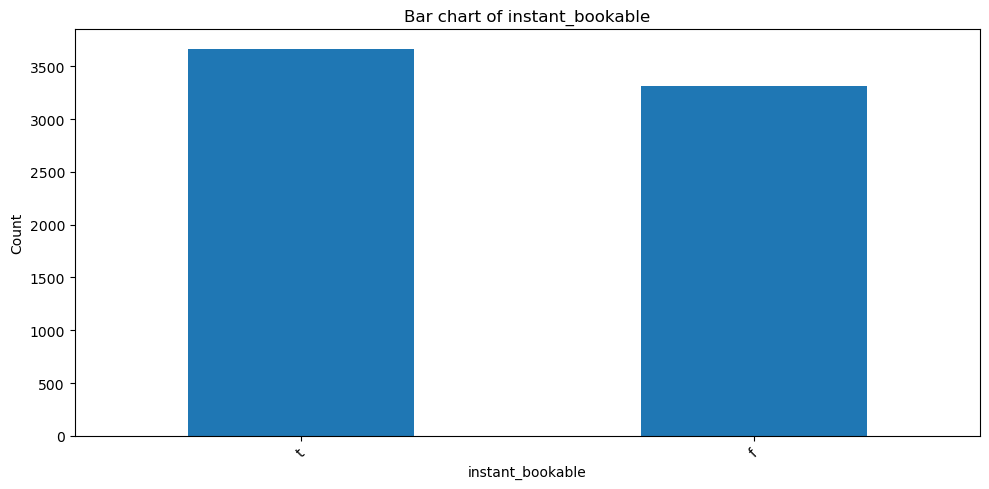

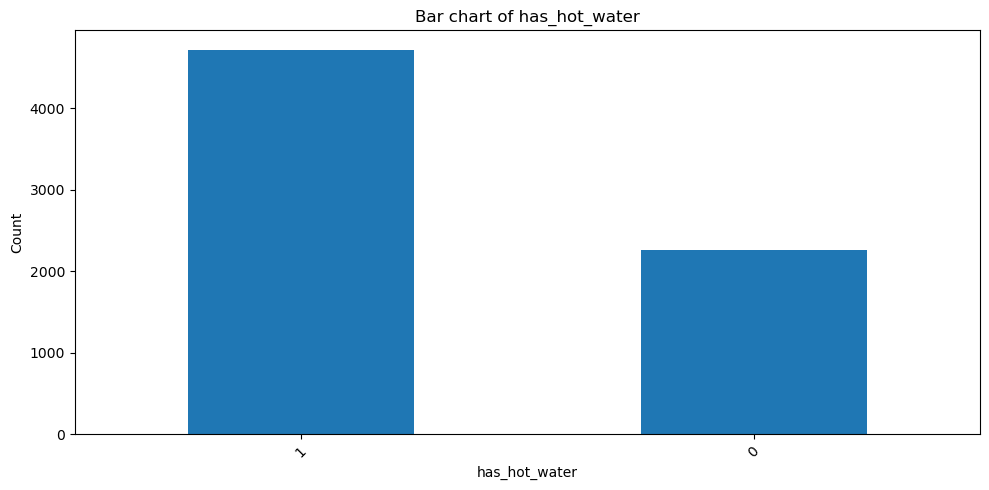

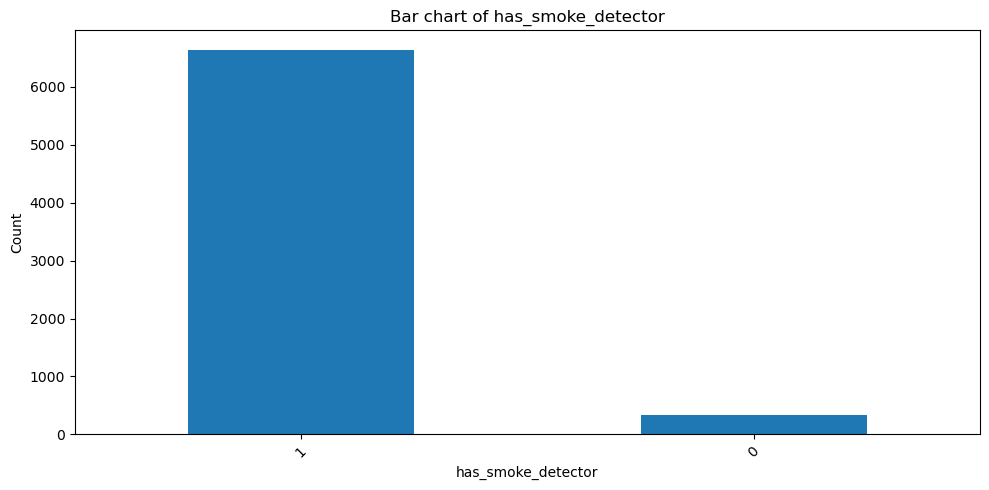

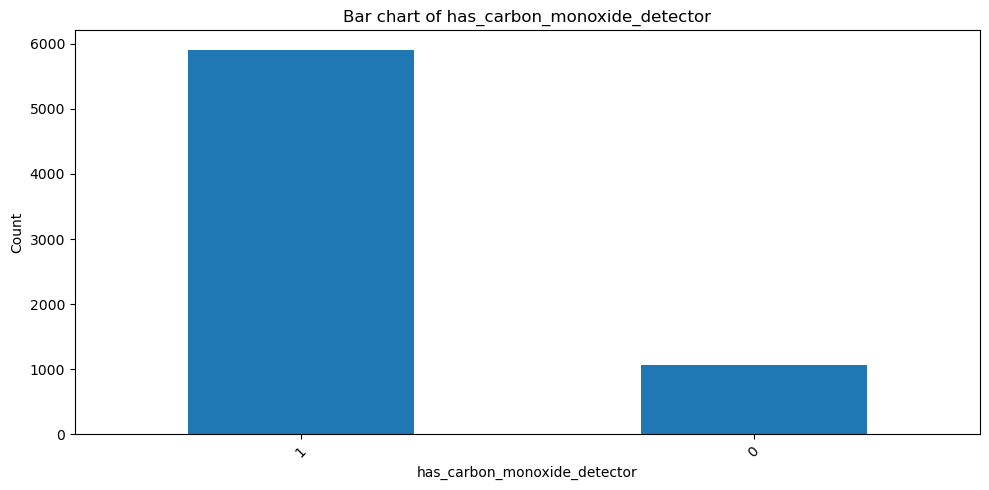

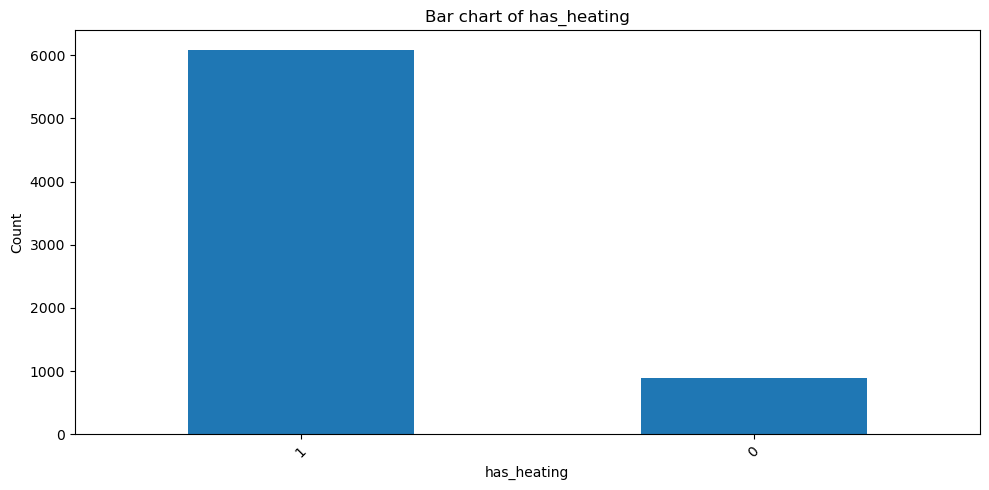

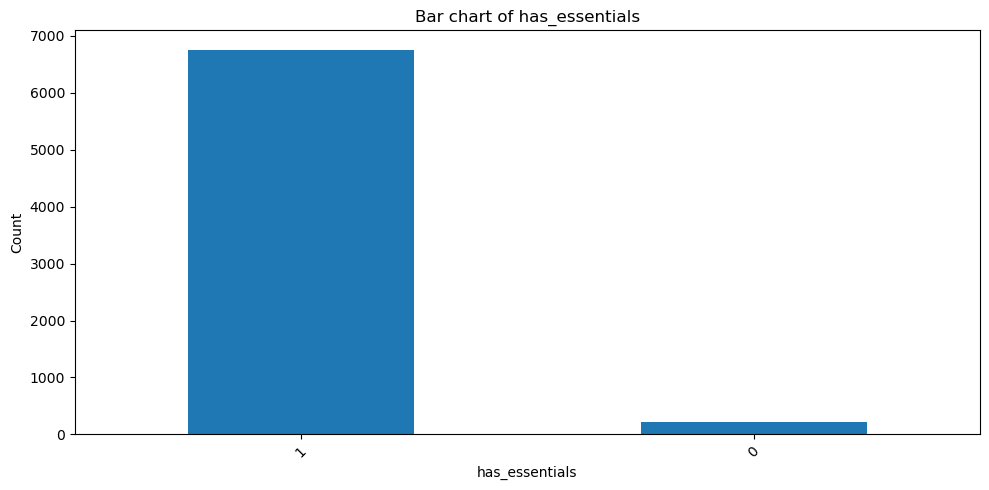

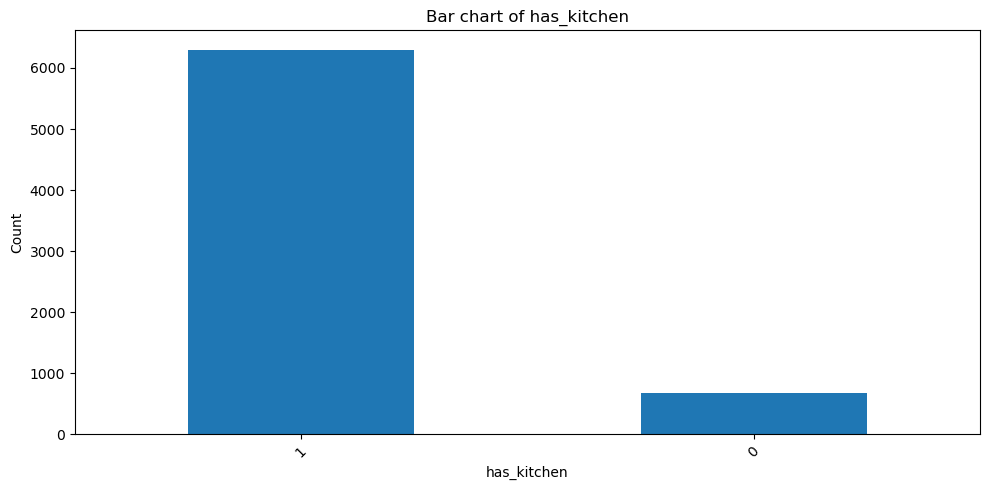

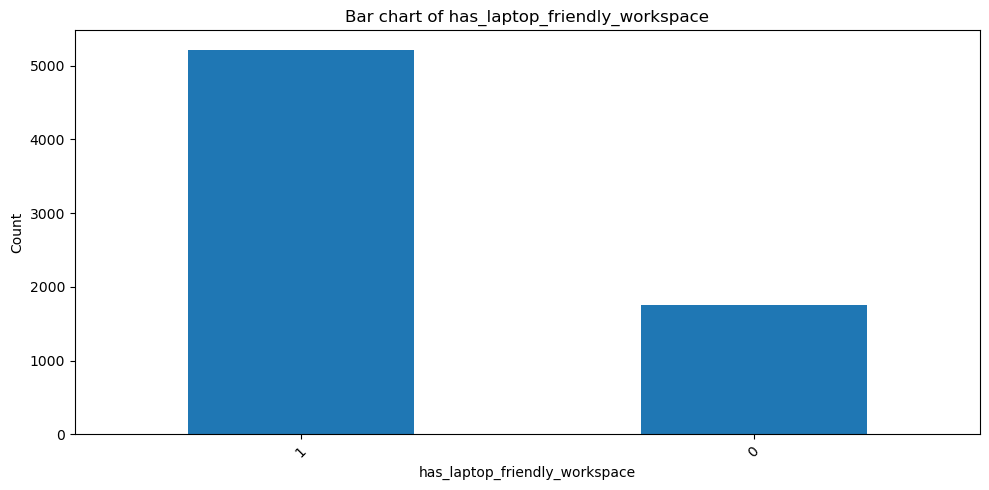

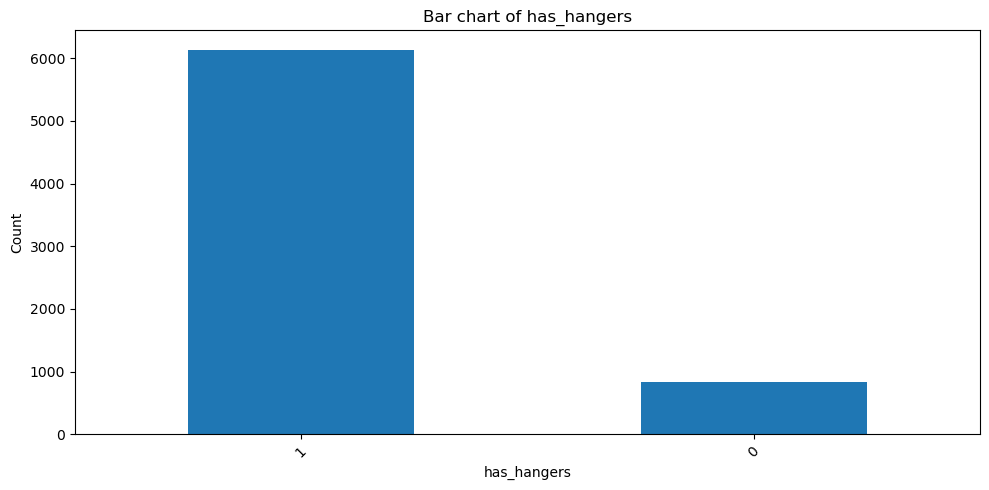

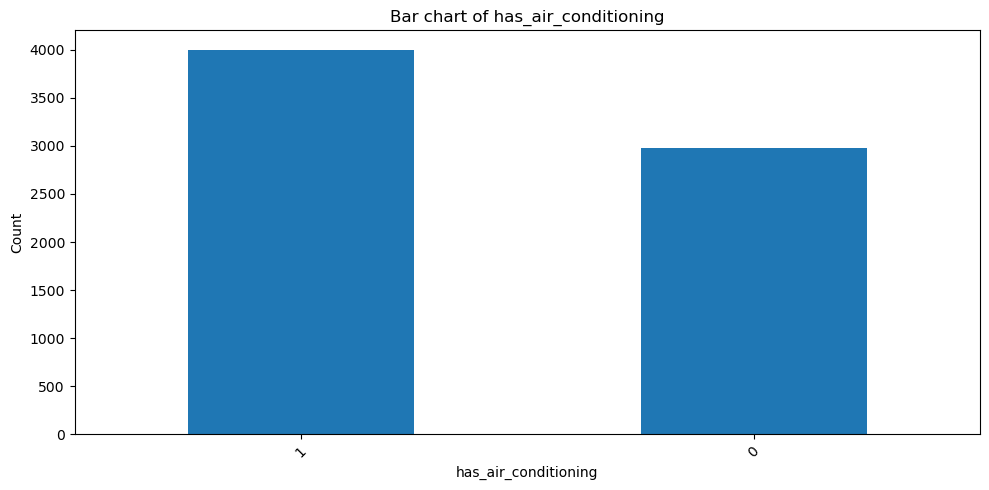

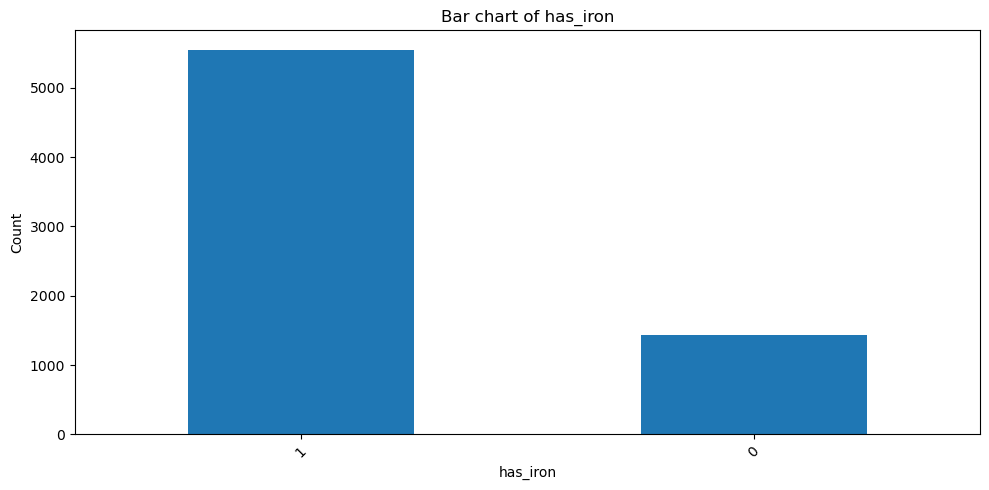

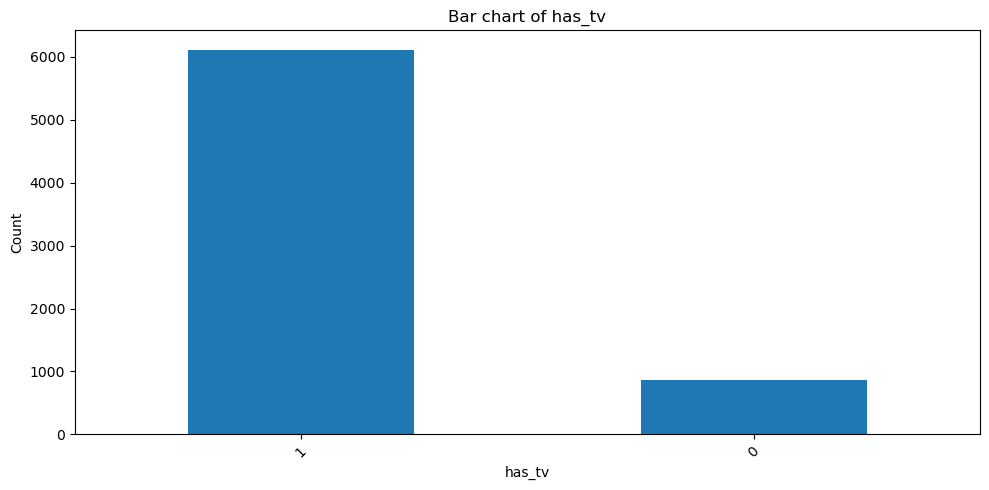

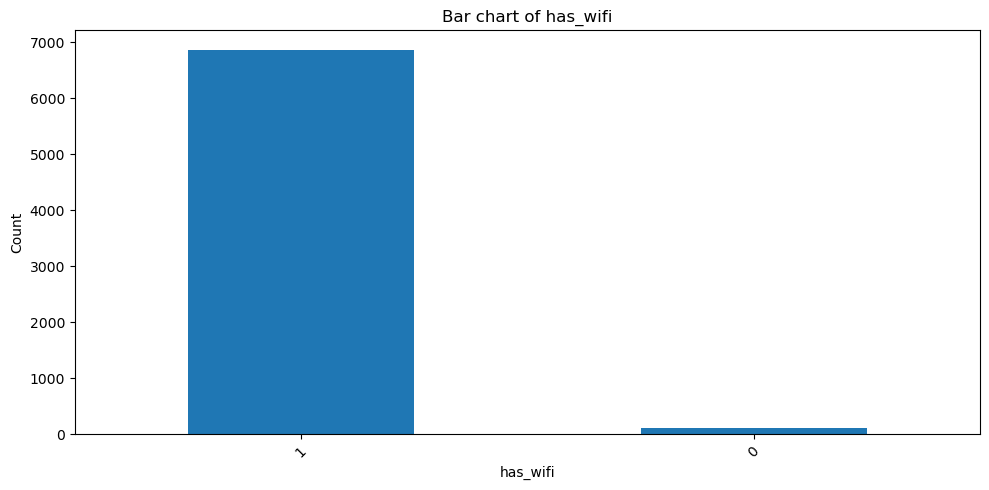

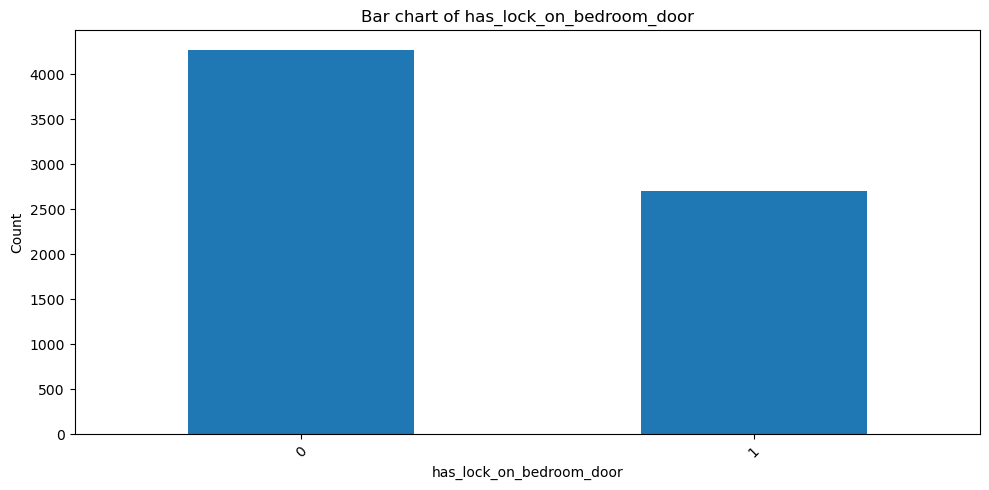

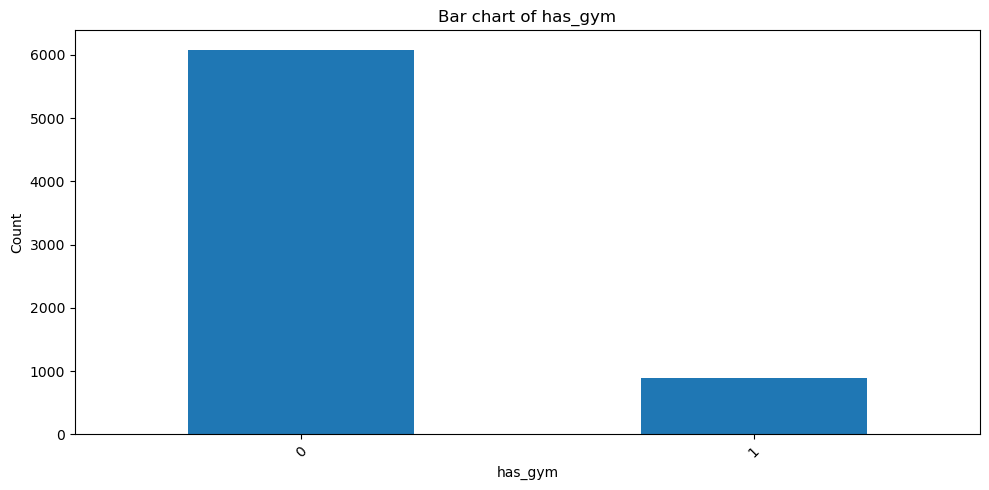

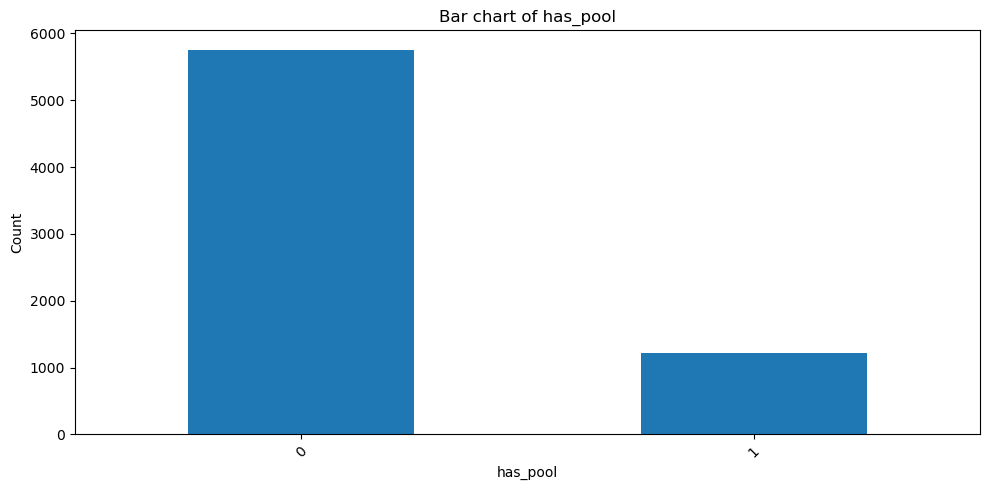

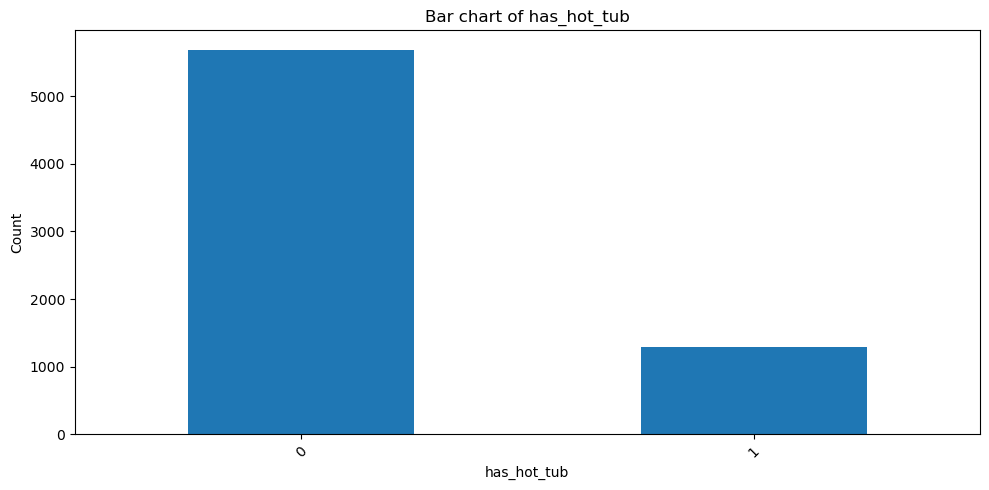

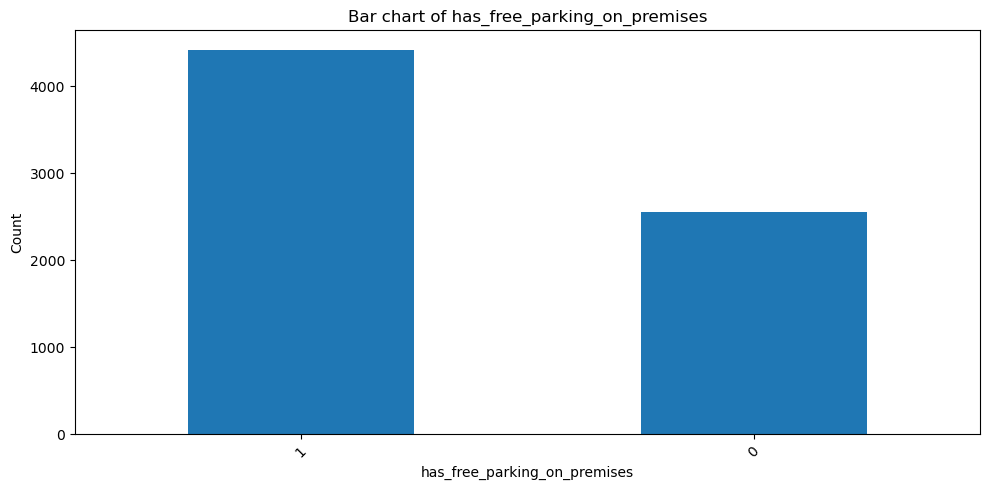

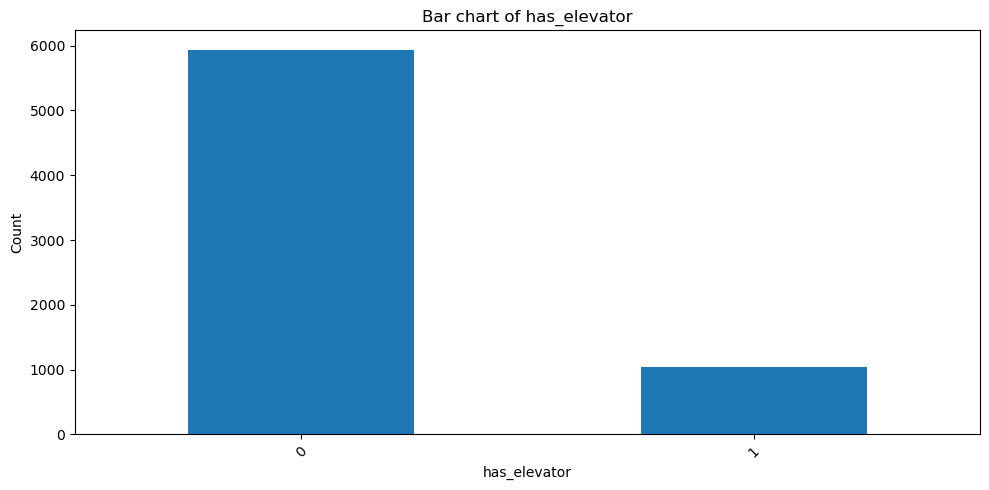

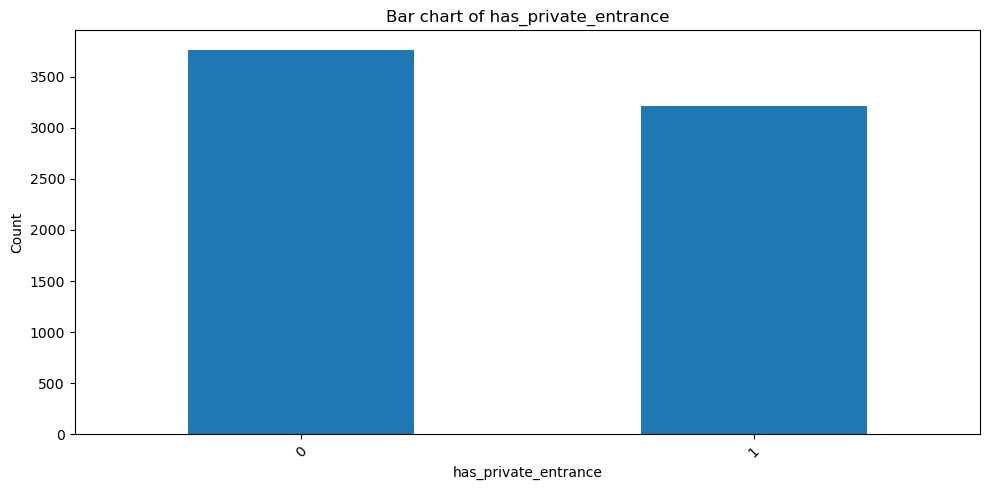

In [12]:
def plot_feature_vs_target(X_train, categorical_cols, target='guest_satisfaction'):
    for col in categorical_cols:
        if col in X_train.columns:
            if X_train[col].nunique() > 0:
                plt.figure(figsize=(10, 5))
                X_train[col].value_counts().head(10).plot(kind='bar')  # top 10 categories
                plt.title(f'Bar chart of {col}')
                plt.xlabel(col)
                plt.ylabel('Count')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
            else:
                print(f"Skipping '{col}' due to no unique values to plot.")
        else:
            print(f"Column '{col}' not found in the DataFrame.")

plot_feature_vs_target(X_train, Categorical_cols)

## **Handling Outliers**

In [13]:
def handle_outliers_iqr(df, numerical_cols, method='cap'):
    for col in numerical_cols:
        # Ensure the column is numeric before calculating quantiles
        if pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            if method == 'remove':
                df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
            elif method == 'cap':
                df[col] = np.where(df[col] < lower_bound, lower_bound,
                          np.where(df[col] > upper_bound, upper_bound, df[col]))
        else:
            print(f"Warning: Skipping non-numeric column '{col}' for outlier handling.")
    return df
X_train = handle_outliers_iqr(X_train, Numerical_cols, method='cap')

# **FILL MISSING VALUES**

In [14]:
columns = ['description', 'transit', 'access', 'interaction', 'house_rules']
X_train[columns] = X_train[columns].fillna('No information provided')

In [15]:
categorical_cols = ['host_location', 'host_is_superhost', 'host_identity_verified']
for col in categorical_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)

In [16]:
X_train['host_neighbourhood'] = X_train.groupby('neighbourhood_cleansed')['host_neighbourhood'] \
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else X_train['host_neighbourhood'].mode()[0]))

X_train['host_neighbourhood'] = X_train['host_neighbourhood'].fillna(X_train['host_neighbourhood'].mode()[0])

X_train['host_response_time'] = X_train.groupby(['host_is_superhost', 'host_response_rate'])['host_response_time'] \
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else X_train['host_response_time'].mode()[0]))

X_train['host_response_time'] = X_train['host_response_time'].fillna(X_train['host_response_time'].mode()[0])

X_train['neighborhood_overview'] = X_train.groupby('neighbourhood_cleansed')['neighborhood_overview'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "No overview available")
)

X_train['neighborhood_overview'] = X_train['neighborhood_overview'].fillna(X_train['neighborhood_overview'].mode()[0])

In [17]:
X_train['host_about'] = X_train.apply(
    lambda row: (
        "is a host offering a {row['room_type']} in {row['neighbourhood_cleansed']}. "
        f"Guests usually enjoy a {row['property_type']} with great hospitality."
        if pd.isnull(row['host_about']) else row['host_about']
    ), axis=1
)

X_train['notes'] = X_train.apply(
    lambda row: (
        f"This {row['room_type']} in {row['neighbourhood_cleansed']} offers a comfortable stay. "
        f"Arrival instructions and local tips will be shared after booking."
        if pd.isnull(row['notes']) else row['notes']
    ), axis=1
)

In [18]:
# Safely strip '%' and convert to float
X_train['host_response_rate'] = X_train['host_response_rate'].astype(str).str.rstrip('%')
X_train['host_response_rate'] = pd.to_numeric(X_train['host_response_rate'], errors='coerce')
X_train['host_response_rate'] = X_train['host_response_rate'].fillna(X_train['host_response_rate'].median())

In [19]:
X_train['zipcode'] = X_train['zipcode'].astype(str).str.extract(r'(\d{5})')[0]

# Define numeric columns
numeric_cols_median = ['zipcode', 'bathrooms', 'bedrooms', 'beds', 'host_listings_count']

# Convert each column to numeric
for col in numeric_cols_median:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')

# Fill NA with median
for col in numeric_cols_median:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)

In [20]:
# Optional numeric financials
X_train['security_deposit'] = X_train['security_deposit'].fillna(0)
X_train['cleaning_fee'] = X_train['cleaning_fee'].fillna(0)

In [21]:
if 'neighbourhood' in X_train.columns:
    X_train.drop('neighbourhood', axis=1, inplace=True)


# Build the summary table
summary = pd.DataFrame({
    'Feature': X_train.columns,
    'Data Type': X_train.dtypes.values,
    'Missing Values': X_train.isnull().sum().values
})

# sort by number of missing values
summary = summary.sort_values(by='Missing Values', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)
print(summary)

                          Feature       Data Type  Missing Values
0                      host_since  datetime64[ns]               1
1                     description          object               0
2                  has_essentials         float64               0
3                  minimum_nights         float64               0
4                  maximum_nights         float64               0
5               number_of_reviews         float64               0
6                 number_of_stays         float64               0
7                    first_review  datetime64[ns]               0
8                     last_review  datetime64[ns]               0
9                instant_bookable          object               0
10            cancellation_policy          object               0
11                  has_hot_water         float64               0
12             has_smoke_detector         float64               0
13   has_carbon_monoxide_detector         float64               0
14        

# **Feature Engineering**

In [22]:
X['review_duration_days'] = (X['last_review'] - X['first_review']).dt.days
X['review_duration_months'] = X['review_duration_days'] / 30
zero_month_count = (X['review_duration_months'] == 0).sum()
total_rows = len(X)
percentage_zero_months = (zero_month_count / total_rows) * 100

print(f"Percentage of zero-month durations: {percentage_zero_months:.2f}%") #hnemla al 8% dool b eh??
print(X[['first_review', 'last_review', 'review_duration_months', 'review_duration_days']].head())
print(X['review_duration_months'].max())
print(X['review_duration_days'].max())

Percentage of zero-month durations: 7.77%
  first_review last_review  review_duration_months  review_duration_days
0   2017-11-17  2017-11-17                0.000000                     0
1   2013-08-02  2019-07-31               72.966667                  2189
2   2017-07-23  2019-07-16               24.100000                   723
3   2018-05-01  2019-08-03               15.300000                   459
4   2019-06-30  2019-06-30                0.000000                     0
129.53333333333333
3886


In [23]:
X['host_since'] = pd.to_datetime(X['host_since'], errors='coerce')
X['host_duration_days'] = (pd.to_datetime("today") - X['host_since']).dt.days
X['host_duration_months'] = X['host_duration_days'] / 30
X['host_duration_years'] = X['host_duration_days'] / 365.25
print(X[['host_since', 'host_duration_days', 'host_duration_months', 'host_duration_years']].head())
print(X['host_duration_days'].max())
print(X['host_duration_months'].max())
print(X['host_duration_years'].max())
#7asa al years ansab 7aga

  host_since  host_duration_days  host_duration_months  host_duration_years
0 2012-10-15              4632.0            154.400000            12.681725
1 2013-01-29              4526.0            150.866667            12.391513
2 2013-11-05              4246.0            141.533333            11.624914
3 2018-04-11              2628.0             87.600000             7.195072
4 2013-08-23              4320.0            144.000000            11.827515
6319.0
210.63333333333333
17.300479123887747


In [24]:
oldest_host_date = X['host_since'].min()
X['host_relative_age_days'] = (X['host_since'] - oldest_host_date).dt.days
X['host_relative_age_months'] = X['host_relative_age_days'] / 30
X['host_relative_age_years'] = X['host_relative_age_days'] / 365.25
print(X[['host_since', 'host_relative_age_days', 'host_relative_age_months', 'host_relative_age_years']].head())
zero_month_count = (X['host_relative_age_days'] == 0).sum()
total_rows = len(X)
percentage_zero_months = (zero_month_count / total_rows) * 100
print(X['host_relative_age_days'].max())
print(X['host_relative_age_months'].max())
print(X['host_relative_age_years'].max())
print(f"Percentage of zero-month durations relative host: {percentage_zero_months:.2f}%")#percentage msh kbeera f eshta
#years ansab 7aga bardoo

  host_since  ...  host_relative_age_years
0 2012-10-15  ...                 4.618754
1 2013-01-29  ...                 4.908966
2 2013-11-05  ...                 5.675565
3 2018-04-11  ...                10.105407
4 2013-08-23  ...                 5.472964

[5 rows x 4 columns]
4176.0
139.2
11.433264887063656
Percentage of zero-month durations relative host: 0.01%


In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   description                    8724 non-null   object        
 1   neighborhood_overview          8724 non-null   object        
 2   notes                          8724 non-null   object        
 3   transit                        8724 non-null   object        
 4   access                         8724 non-null   object        
 5   interaction                    8724 non-null   object        
 6   house_rules                    8724 non-null   object        
 7   host_id                        8724 non-null   int64         
 8   host_since                     8723 non-null   datetime64[ns]
 9   host_location                  8724 non-null   object        
 10  host_about                     8724 non-null   object        
 11  host_response_tim

In [26]:
# Drop the original date columns from X after creating the new duration/age features
drop_columns = ['first_review', 'last_review', 'host_since']
# Check if columns exist
existing_drop_columns = [col for col in drop_columns if col in X.columns]
if existing_drop_columns:
    X.drop(columns=existing_drop_columns, inplace=True)
else:
    print("Date columns already dropped from X or do not exist.")

In [27]:
# Host Features
X['host_response_rate'] = X['host_response_rate'].str.rstrip('%').astype(float)
X['host_response_power'] = X['host_response_rate'] * np.log1p(X['host_listings_count'])
X['host_commitment'] = X['host_duration_days'] / (X['number_of_stays'] + 1)


In [28]:
# Property Quality Indicators
X['bedroom_quality'] = X['bedrooms'] / (X['bathrooms'] + 0.5)
X['space_per_guest'] = X['accommodates'] / (X['beds'] + 0.1)

In [29]:
#Features related to time
X['seasonal_demand'] = np.sin(2 * np.pi * (X['host_duration_days'] % 365) / 365)
X['recent_review_boost'] = np.where(X['review_duration_days'] < 30, 1, 0.5)

In [30]:
#Amenity Combinations
X['essential_amenities'] = X[['has_wifi', 'has_air_conditioning', 'has_kitchen']].sum(axis=1)
X['luxury_amenities'] = X[['has_hot_tub', 'has_pool', 'has_gym']].sum(axis=1)

In [31]:
# Feature to evaluate value for money
X['price_value'] = X['nightly_price'] / X['accommodates']

# **Feature selection**

In [34]:
df['guest_satisfaction'].value_counts()

guest_satisfaction
Very High    4188
Average      2546
High         1990
Name: count, dtype: int64

In [35]:
#feature selection by Chi-square(categorical features)
features = X_train.copy()
target = y_train.copy()

# select categorical columns
categorical_cols = features.select_dtypes(include='object').columns.tolist()

# One-hot encode categorical columns
X_cat = pd.get_dummies(features[categorical_cols])

le = LabelEncoder()
y_encoded = le.fit_transform(target)

selector = SelectKBest(score_func=chi2, k='all')
X_new = selector.fit_transform(X_cat, y_encoded)

scores = selector.scores_
feature_names = X_cat.columns

selected_features = pd.DataFrame({'Feature': feature_names, 'Chi2 Score': scores})
selected_features = selected_features.sort_values(by='Chi2 Score', ascending=False)

# select top 10 features
top_n = 10
top_features = selected_features.head(top_n)
print(top_features)

                                                 Feature  Chi2 Score
33933                                host_is_superhost_t  522.077488
33932                                host_is_superhost_f  370.737702
26887  house_rules_1 priority insuring valued guest e...   80.167880
33545  host_about_since 2002 providing ever improving...   80.167880
34213                            property_type_apartment   77.648156
34249                       cancellation_policy_moderate   61.522700
34248                       cancellation_policy_flexible   58.767361
34132                neighbourhood_cleansed_east village   57.461002
32765               host_about_living dream one day time   53.153206
14557                                           transit_   49.889942


In [36]:
def get_original_column(dummy_col, original_cols):
    matches = [col for col in original_cols if dummy_col.startswith(col)]
    if matches:
        # Return the longest matching original column name
        return max(matches, key=len)
    else:
        return dummy_col

original_cols = [get_original_column(col, categorical_cols) for col in top_features['Feature']]
original_cols = sorted(set(original_cols))

print("\nSelected original categorical column names:")
print(original_cols)


Selected original categorical column names:
['cancellation_policy', 'host_about', 'host_is_superhost', 'house_rules', 'neighbourhood_cleansed', 'property_type', 'transit']


In [37]:
#feature selection by anova(numerical features)
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

X_train_clean = X_train[numerical_cols].copy()
X_train_clean = X_train_clean.apply(pd.to_numeric, errors='coerce')

for col in numerical_cols:
    if X_train_clean[col].isna().any():
        median_val = X_train_clean[col].median()
        X_train_clean[col] = X_train_clean[col].fillna(median_val)

# remove constant features
constant_features = [col for col in numerical_cols if X_train_clean[col].nunique() == 1]
if constant_features:
    print(f"Removed constant features: {constant_features}")
    numerical_cols = numerical_cols.drop(constant_features)
    X_train_clean = X_train_clean.drop(columns=constant_features)

if len(numerical_cols) > 0:
    F_values, p_values = f_classif(X_train_clean, y_train)

    full_results = pd.DataFrame({
        'Feature': numerical_cols,
        'F-Statistic': F_values,
        'p-value': p_values
    }).sort_values(by='F-Statistic', ascending=False)

    print("\nANOVA Results for All Features:")
    print(full_results.to_string(index=False))

    top_10 = full_results.head(10)
    print("\nTop 10 Features by F-Statistic:")
    print(top_10.to_string(index=False))

    significant_features = full_results[full_results['p-value'] < 0.05]
    if not significant_features.empty:
        print("\nTop 10 Statistically Significant Features (p-value < 0.05):")
        print(significant_features.head(10).to_string(index=False))
    else:
        print("\nNo features with statistically significant ANOVA results (p-value < 0.05)")
else:
    print("No valid numerical features available for ANOVA after preprocessing")

Removed constant features: ['has_smoke_detector', 'has_carbon_monoxide_detector', 'has_heating', 'has_essentials', 'has_kitchen', 'has_hangers', 'has_iron', 'has_tv', 'has_wifi', 'has_gym', 'has_pool', 'has_hot_tub', 'has_elevator']

ANOVA Results for All Features:
                      Feature  F-Statistic      p-value
          host_listings_count   213.169657 1.381469e-90
              number_of_stays   187.171005 6.586422e-80
            number_of_reviews   187.171005 6.586422e-80
     has_lock_on_bedroom_door    47.295093 3.962876e-21
                has_hot_water    40.421315 3.517102e-18
               maximum_nights    35.472927 4.700179e-16
               minimum_nights    32.787720 6.714050e-15
has_laptop_friendly_workspace    29.120424 2.544845e-13
                 accommodates    25.648950 7.971844e-12
         has_air_conditioning    24.052887 3.888807e-11
                         beds    22.026148 2.912342e-10
                 cleaning_fee    16.692535 5.858898e-08
      

# **ENCODING**

In [38]:
X_train = X_train.replace({
    'require_guest_phone_verification': {'t': 1, 'f': 0},
    'require_guest_profile_picture': {'t': 1, 'f': 0},
    'instant_bookable': {'t': 1, 'f': 0},
    'is_location_exact': {'t': 1, 'f': 0},
    'host_identity_verified': {'t': 1, 'f': 0},
    'host_has_profile_pic': {'t': 1, 'f': 0},
    'is_business_travel_ready': {'t': 1, 'f': 0},
    'host_is_superhost': {'t': 1, 'f': 0},
    'requires_license': {'t': 1, 'f': 0}
})
X_test = X_test.replace({
    'require_guest_phone_verification': {'t': 1, 'f': 0},
    'require_guest_profile_picture': {'t': 1, 'f': 0},
    'instant_bookable': {'t': 1, 'f': 0},
    'is_location_exact': {'t': 1, 'f': 0},
    'host_identity_verified': {'t': 1, 'f': 0},
    'host_has_profile_pic': {'t': 1, 'f': 0},
    'is_business_travel_ready': {'t': 1, 'f': 0},
    'host_is_superhost': {'t': 1, 'f': 0},
    'requires_license': {'t': 1, 'f': 0}
})


In [39]:
label_cols = [
    'cancellation_policy',
    'room_type',
    'property_type',
    'host_identity_verified',
]

encoders = {}

for col in label_cols:
    le = LabelEncoder()
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    all_values = pd.concat([X_train[col], X_test[col]]).unique()
    le.fit(all_values)

    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

In [40]:
mapping = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

X_train['host_response_time'] = X_train['host_response_time'].map(mapping)
X_test['host_response_time'] = X_test['host_response_time'].map(mapping)

In [41]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

with open('y_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [42]:
preprocessed_train = X_train.join(y_train)
preprocessed_test = X_test.join(y_test)

preprocessed_train.to_csv('preprocessed_train.csv')
preprocessed_test.to_csv('preprocessed_test.csv')

In [43]:
for df in [X_train, X_test]:
    for col in df.columns:
        if df[col].dtype == object and df[col].str.contains('%').any():
            df[col] = df[col].str.replace('%', '', regex=False).astype(float)

# select columns
num_cols = X_train.select_dtypes(include='number').columns.tolist()
binary_cols = [c for c in num_cols if X_train[c].nunique() == 2]
cont_cols = [c for c in num_cols if c not in binary_cols]
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# pipelines
binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

continuous_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('bin', binary_transformer, binary_cols),
    ('cont', continuous_transformer, cont_cols),
    ('cat', categorical_transformer, cat_cols)
])


# **Loading Preprocessed Data into files**

In [46]:
df_train = X_train.copy()
df_train['guest_satisfaction'] = y_train_encoded

df_test = X_test.copy()
df_test['guest_satisfaction'] = y_test_encoded

In [47]:
df_train.to_csv('df_train.csv', index=False)
df_test.to_csv('df_test.csv', index=False)